In [7]:
from pm4py.objects.log.importer.xes import importer as xes_importer

path_log = '/Users/francescameneghello/Documents/GitHub/nirdizati-light/datasets/SynLoan/full_51_days.xes'
log = xes_importer.apply(path_log)

parsing log, completed traces ::   0%|          | 0/2000 [00:00<?, ?it/s]

In [2]:
def add_label_SynLoan(trace):
    flag = 'regular'
    for event in trace:
        if event['concept:name'] == 'O_ACCEPTED':
            flag = 'deviant'
    return flag

In [68]:
def check_SynLoan(trace):
    flag = 'regular'
    time = (trace[-1]['time:timestamp'] - trace[0]['start:timestamp']).total_seconds()
    time = round(time/86400)
    if time >= 23:
        flag = 'deviant'
    return flag

In [4]:
def check_trace_BPI12(trace):
    idx = 0
    flag = True
    while idx < len(trace) and flag:
        if trace[idx]['concept:name'] == 'W_Nabellen incomplete dossiers':
            flag = False
        else:
            idx += 1
    if flag == False:
        if trace[-1]['concept:name'] == 'W_Valideren aanvraag' or trace[-1]['concept:name'] == 'W_Completeren aanvraag':
            flag = True
    
    return 'deviant' if flag == False else 'regular'

In [17]:
def check_trace_PurchasingExample(trace):
    flag = 'regular'
    for idx, event in enumerate(trace):
        if event['concept:name'] == 'Settle Dispute With Supplier':
            if idx+1 < len(trace) and trace[idx+1]['concept:name'] == 'Release Purchase Order':
                flag = 'deviant'
    return flag

In [8]:
for trace in log:
    label = add_label_SynLoan(trace)
    trace.attributes['label'] = label

In [72]:
192/len(log)

0.8727272727272727

In [71]:
regular = 0
for trace in log:
    if trace.attributes['label'] == 'regular':
        regular += 1
regular

192

In [21]:
len(log) - 584

24

In [15]:
import pm4py
pm4py.write_xes(log, '/Users/francescameneghello/Documents/GitHub/nirdizati-light/datasets/BPI_Challenge_2012_W_Two_TS/full_incomplete.xes')

exporting log, completed traces ::   0%|          | 0/8615 [00:00<?, ?it/s]

In [66]:
pm4py.write_xes(log, '/Users/francescameneghello/Documents/GitHub/nirdizati-light/datasets/PurchasingExample/full_75_days.xes')

exporting log, completed traces ::   0%|          | 0/608 [00:00<?, ?it/s]

In [9]:
import pm4py
pm4py.write_xes(log, '/Users/francescameneghello/Documents/GitHub/nirdizati-light/datasets/SynLoan/labelling_generate.xes')

exporting log, completed traces ::   0%|          | 0/2000 [00:00<?, ?it/s]

In [73]:
pm4py.write_xes(log, '/Users/francescameneghello/Documents/GitHub/nirdizati-light/datasets/Productions/full_23_days.xes')

exporting log, completed traces ::   0%|          | 0/220 [00:00<?, ?it/s]

In [74]:
from pm4py.objects.log.importer.xes import importer as xes_importer

path_log = '/Users/francescameneghello/Documents/GitHub/nirdizati-light/datasets/PurchasingExample/full.xes'
log = xes_importer.apply(path_log)

parsing log, completed traces ::   0%|          | 0/608 [00:00<?, ?it/s]

In [75]:
len(deviant_caseid)

195

In [76]:
deviant_caseid = []
for trace in log:
    if trace.attributes['label'] == 'deviant':
        deviant_caseid.append(trace.attributes['concept:name'])
deviant_caseid

['100',
 '1004',
 '1008',
 '1015',
 '1021',
 '1022',
 '1023',
 '1025',
 '104',
 '1041',
 '1047',
 '1057',
 '106',
 '1079',
 '1085',
 '109',
 '1094',
 '11',
 '1104',
 '1114',
 '1123',
 '1144',
 '1151',
 '1153',
 '1158',
 '1182',
 '1187',
 '1192',
 '1197',
 '1214',
 '1242',
 '125',
 '1282',
 '1287',
 '1290',
 '1294',
 '1300',
 '1305',
 '1337',
 '1347',
 '1353',
 '1360',
 '1362',
 '1367',
 '1368',
 '137',
 '1377',
 '1378',
 '1380',
 '1386',
 '1387',
 '139',
 '1395',
 '1404',
 '1417',
 '143',
 '1452',
 '1457',
 '1463',
 '1477',
 '1488',
 '1499',
 '1500',
 '1506',
 '151',
 '1511',
 '1558',
 '156',
 '157',
 '1585',
 '1596',
 '160',
 '1613',
 '1624',
 '1626',
 '17',
 '172',
 '1722',
 '1725',
 '1749',
 '175',
 '1759',
 '1770',
 '1773',
 '1789',
 '1796',
 '1817',
 '1852',
 '1857',
 '1871',
 '1873',
 '1874',
 '1892',
 '1909',
 '1917',
 '192',
 '1920',
 '1929',
 '1938',
 '1941',
 '1949',
 '195',
 '205',
 '209',
 '211',
 '216',
 '220',
 '237',
 '251',
 '252',
 '257',
 '260',
 '268',
 '283',
 '287'

In [80]:
import random
filter_caseid = random.sample(deviant_caseid, 180)

In [81]:
event_log = pm4py.convert_to_dataframe(log)

In [82]:
filter_df =  event_log[~event_log['case:concept:name'].isin(filter_caseid)]
event_log_xes = pm4py.convert_to_event_log(filter_df)

print(len(event_log_xes))

pm4py.write_xes(event_log_xes, '/Users/francescameneghello/Documents/GitHub/nirdizati-light/datasets/PurchasingExample/full_filtered.xes')

428


exporting log, completed traces ::   0%|          | 0/428 [00:00<?, ?it/s]

In [41]:
for trace in event_log_xes:
    

578

In [33]:
import pandas as pd

df = pd.read_csv('/Users/francescameneghello/Downloads/data 2/Production_Data.csv', sep=',')

In [34]:
df

,Case ID,Activity,Resource,Start Timestamp,Complete Timestamp,Span,Work Order Qty,Part Desc.,Worker ID,Report Type,Qty Completed,Qty Rejected,Qty for MRB,Rework
0,Case 1,Turning & Milling - Machine 4,Machine 4 - Turning & Milling,2012/01/29 23:24:00.000,2012/01/30 05:43:00.000,006:19,10,Cable Head,ID4932,S,1,0,0,NaN
1,Case 1,Turning & Milling - Machine 4,Machine 4 - Turning & Milling,2012/01/30 05:44:00.000,2012/01/30 06:42:00.000,000:58,10,Cable Head,ID4932,D,1,0,0,NaN
2,Case 1,Turning & Milling - Machine 4,Machine 4 - Turning & Milling,2012/01/30 06:59:00.000,2012/01/30 07:21:00.000,000:22,10,Cable Head,ID4167,S,0,0,0,NaN
3,Case 1,Turning & Milling - Machine 4,Machine 4 - Turning & Milling,2012/01/30 07:21:00.000,2012/01/30 10:58:00.000,003:37,10,Cable Head,ID4167,D,8,0,0,NaN
4,Case 1,Turning & Milling Q.C.,Quality Check 1,2012/01/31 13:20:00.000,2012/01/31 14:50:00.000,001:30,10,Cable Head,ID4163,D,9,1,0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4538,Case 99,Laser Marking - Machine 7,Machine 7- Laser Marking,2012/03/26 09:14:00.000,2012/03/26 10:12:00.000,000:58,507,Drill,ID0998,D,160,0,0,NaN
4539,Case 99,Lapping - Machine 1,Machine 1 - Lapping,2012/03/26 10:12:00.000,2012/03/26 12:12:00.000,002:00,507,Drill,ID0998,D,160,0,0,NaN
4540,Case 99,Final Inspection Q.C.,Quality Check 1,2012/03/28 17:35:00.000,2012/03/28 17:59:00.000,000:24,507,Drill,ID4618,D,0,0,0,NaN
4541,Case 99,Final Inspection Q.C.,Quality Check 1,2012/03/29 08:00:00.000,2012/03/29 11:54:00.000,003:54,507,Drill,ID4618,D,160,0,0,NaN


In [35]:
df['Activity'] = df['Activity'].apply(lambda x: x[:x.find('-')-1])

In [38]:
df['Activity']

0          Turning & Milling
1          Turning & Milling
2          Turning & Milling
3          Turning & Milling
4       Turning & Milling Q.
                ...         
4538           Laser Marking
4539                 Lapping
4540     Final Inspection Q.
4541     Final Inspection Q.
4542                   Packi
Name: Activity, Length: 4543, dtype: object

In [40]:
unique_values = df["Part Desc."].unique()
print(unique_values)

['Cable Head' 'Spur Gear' 'Ballnut' 'Housing' 'Adjusting Nut' 'Bearing'
 'Bushing' 'Electrical Contact' 'Clamp' 'Wheel Shaft' 'Cylinder' 'Plug'
 'Locker' 'Spring' 'Piston' 'Ring' 'Drill' 'Spinner' 'Punch Holder' 'Tube'
 'Seal Head' 'Socket' 'Slip Ring Adapter' 'Punch Plate' 'Gauge' 'O-Ring'
 'Cutting Wheel' 'Flange' 'Shim' 'Flange Bolt' 'Fastener' 'Disc' 'Barrel'
 'Blade' 'Compound Dies' 'Locknut' 'Cast' 'Wheel' 'Assembly 1' 'Spindle'
 'Adapter' 'Drum' 'Hinge']


In [42]:
{i: e for i, e in enumerate(unique_values)}

{0: 'Cable Head',
 1: 'Spur Gear',
 2: 'Ballnut',
 3: 'Housing',
 4: 'Adjusting Nut',
 5: 'Bearing',
 6: 'Bushing',
 7: 'Electrical Contact',
 8: 'Clamp',
 9: 'Wheel Shaft',
 10: 'Cylinder',
 11: 'Plug',
 12: 'Locker',
 13: 'Spring',
 14: 'Piston',
 15: 'Ring',
 16: 'Drill',
 17: 'Spinner',
 18: 'Punch Holder',
 19: 'Tube',
 20: 'Seal Head',
 21: 'Socket',
 22: 'Slip Ring Adapter',
 23: 'Punch Plate',
 24: 'Gauge',
 25: 'O-Ring',
 26: 'Cutting Wheel',
 27: 'Flange',
 28: 'Shim',
 29: 'Flange Bolt',
 30: 'Fastener',
 31: 'Disc',
 32: 'Barrel',
 33: 'Blade',
 34: 'Compound Dies',
 35: 'Locknut',
 36: 'Cast',
 37: 'Wheel',
 38: 'Assembly 1',
 39: 'Spindle',
 40: 'Adapter',
 41: 'Drum',
 42: 'Hinge'}

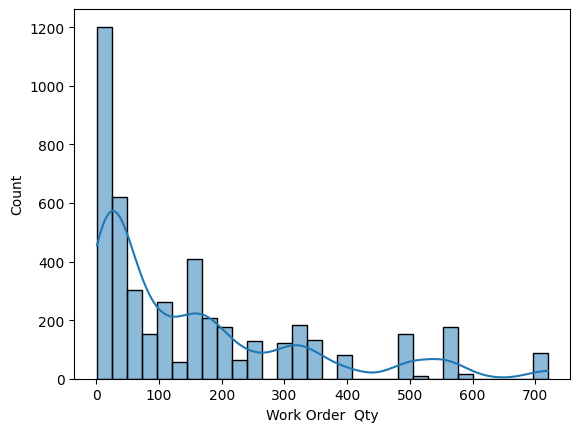

In [43]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.histplot(df["Work Order  Qty"], kde=True, bins=30)
plt.show()

In [50]:
import scipy.stats as stats

data = df["Work Order  Qty"]
dist_names = ["norm", "expon", "gamma", "weibull_min", "lognorm"]

best_fit = None
best_ks = float("inf")

for dist_name in dist_names:
    dist = getattr(stats, dist_name)
    params = dist.fit(data)
    
    ks_statistic, _ = stats.kstest(data, dist_name, args=params)
    if ks_statistic < best_ks:
        best_ks = ks_statistic
        best_fit = (dist_name, params)

print("Best fitting distribution:", best_fit[0])
print("Parameters:", best_fit[1])


Best fitting distribution: weibull_min
Parameters: (0.8250050395251411, 0.9999999999999999, 141.17215975566398)


In [53]:
best_fit

('weibull_min', (0.8250050395251411, 0.9999999999999999, 141.17215975566398))

In [52]:
best_dist = getattr(stats, best_fit[0])
best_dist.rvs(*best_fit[1], size=1)


array([155.4753411])

In [55]:
category_distribution_normalized = df["Part Desc."].value_counts(normalize=True)
print(category_distribution_normalized)


Part Desc.
Cable Head            0.284173
Ballnut               0.192604
Spur Gear             0.092450
Housing               0.043143
Punch Holder          0.038081
Plug                  0.026855
Bearing               0.026194
Piston                0.022012
Gauge                 0.020031
Adapter               0.019591
Spindle               0.016509
Drill                 0.016069
Clamp                 0.014308
Spinner               0.014088
Socket                0.013207
Fastener              0.012987
Punch Plate           0.011886
Electrical Contact    0.011226
Flange                0.010786
Tube                  0.010786
Cast                  0.008805
Flange Bolt           0.008585
Shim                  0.008144
Wheel Shaft           0.007264
Drum                  0.006383
Ring                  0.005943
Adjusting Nut         0.005723
Locknut               0.005063
Compound Dies         0.004843
Bushing               0.004843
O-Ring                0.004402
Wheel                 0.0039

In [62]:
import numpy as np

categories = category_distribution_normalized.index
probabilities = category_distribution_normalized.values
print(categories)
print(list(probabilities))
generated_samples = np.random.choice(categories, size=1, p=probabilities)[0]


Index(['Cable Head', 'Ballnut', 'Spur Gear', 'Housing', 'Punch Holder', 'Plug',
       'Bearing', 'Piston', 'Gauge', 'Adapter', 'Spindle', 'Drill', 'Clamp',
       'Spinner', 'Socket', 'Fastener', 'Punch Plate', 'Electrical Contact',
       'Flange', 'Tube', 'Cast', 'Flange Bolt', 'Shim', 'Wheel Shaft', 'Drum',
       'Ring', 'Adjusting Nut', 'Locknut', 'Compound Dies', 'Bushing',
       'O-Ring', 'Wheel', 'Hinge', 'Blade', 'Barrel', 'Slip Ring Adapter',
       'Cutting Wheel', 'Assembly 1', 'Cylinder', 'Disc', 'Locker', 'Spring',
       'Seal Head'],
      dtype='object', name='Part Desc.')
[0.2841734536649791, 0.1926040061633282, 0.09244992295839753, 0.04314329738058552, 0.03808056350429232, 0.02685450143077262, 0.026194144838212634, 0.02201188641866608, 0.020030816640986132, 0.019590578912612813, 0.016508914813999558, 0.01606867708562624, 0.014307726172132952, 0.01408760730794629, 0.013207131851199648, 0.012987012987012988, 0.011886418666079684, 0.011226062073519701, 0.0107858243451

In [59]:
generated_samples

'Barrel'

In [39]:
df.to_csv('/Users/francescameneghello/Downloads/data 2/Production_Data_act.csv', sep=',', index=False)

In [26]:
import numpy as np
np.percentile([1603330.0, 2281685.0, 2465285.0], 95)

2446925.0

In [30]:
import random

random.random()*100

33.1566778140928

In [11]:
###### EVALUATION WITH METRICS 

import pandas as pd

from log_distance_measures.config import EventLogIDs
from log_distance_measures.control_flow_log_distance import control_flow_log_distance
from log_distance_measures.circadian_event_distribution import circadian_event_distribution_distance
from log_distance_measures.config import AbsoluteTimestampType, DEFAULT_CSV_IDS, discretize_to_hour
from log_distance_measures.relative_event_distribution import relative_event_distribution_distance
from log_distance_measures.n_gram_distribution import n_gram_distribution_distance
from log_distance_measures.config import AbsoluteTimestampType, DEFAULT_CSV_IDS, discretize_to_hour
from log_distance_measures.relative_event_distribution import relative_event_distribution_distance
from log_distance_measures.circadian_event_distribution import circadian_event_distribution_distance
from log_distance_measures.config import AbsoluteTimestampType, DEFAULT_CSV_IDS
from log_distance_measures.absolute_event_distribution import absolute_event_distribution_distance
from log_distance_measures.case_arrival_distribution import case_arrival_distribution_distance
from log_distance_measures.cycle_time_distribution import cycle_time_distribution_distance
import glob
import pandas as pd
from log_distance_measures.config import DistanceMetric
from log_distance_measures.earth_movers_distance import earth_movers_distance

In [83]:
from log_distance_measures.circadian_workforce_distribution import circadian_workforce_distribution_distance


# Set event log column ID mapping
event_log_ids = EventLogIDs(  # These values are stored in DEFAULT_CSV_IDS
    case="Case ID",
    activity="Activity",
    end_time="Complete Timestamp",
    start_time="Complete Timestamp"
)

# Read and transform time attributes
original_log = pd.read_csv("/Users/francescameneghello/Downloads/processed_benchmark_event_logs/Production_m.csv")
original_log[event_log_ids.start_time] = pd.to_datetime(original_log[event_log_ids.start_time], utc=True)
original_log[event_log_ids.end_time] = pd.to_datetime(original_log[event_log_ids.end_time], utc=True)
#method = ['Simplex_DT', 'Simplex_PR', 'Last_DT', 'Last_PR', 'Plus_Last_DT', 'Plus_Last_PR']
method = ['RIMS', 'VAE']
#metrics = ['CLFD', '2-Gram', '3-Gram', 'cwd']
matrics = ['cwd']
event_log_VAE = EventLogIDs(  # These values are stored in DEFAULT_CSV_IDS
    case="Case ID",
    activity="Activity",
    end_time="time:timestamp",
    start_time="time:timestamp"
)

path_dict = {
    'VAE': ['/Users/francescameneghello/Downloads/gen 2/gen1.csv', event_log_VAE],
    'RIMS': ['/Users/francescameneghello/Documents/GitHub/RIMS/Productions/results/rims/simulated_log_LSTM_Productions0.csv', event_log_ids]
}

results = {}
for m in metrics:
    #print('Metrics', m)
    results[m] = {}
    for t in method:
        #print(t)
        all_file = glob.glob(path_dict[t][0])
        results[m][t] = [] 
        for i, file in enumerate(all_file):
            if t == 'VAE':
                simulated_log = pd.read_csv(file, sep =";")
            else:
                simulated_log = pd.read_csv(file)
            simulated_log[path_dict[t][1].start_time] = pd.to_datetime(simulated_log[path_dict[t][1].start_time], utc=True)
            simulated_log[path_dict[t][1].end_time] = pd.to_datetime(simulated_log[path_dict[t][1].end_time], utc=True)
            #if m == 'CLFD':
            #       distance = control_flow_log_distance(
            #            original_log, event_log_ids,  # First event log and its column id mappings
            #            simulated_log, path_dict[t][1]
            #       )    
            #elif m == '2-Gram':
            #    distance = n_gram_distribution_distance(
            #        original_log, event_log_ids,  # First event log and its column id mappings
            #        simulated_log, path_dict[t][1],
            #        n = 2
            #    )
            #else:
            #    distance = n_gram_distribution_distance(
            #        original_log, event_log_ids,  # First event log and its column id mappings
            #        simulated_log, path_dict[t][1],
            #        n = 3
            #    )
            if m == 'cwd':
               
                distance = circadian_workforce_distribution_distance(
                    original_log, event_log_ids,  # First event log and its column id mappings
                    simulated_log, event_log_ids,  # Second event log and its column id mappings
                )
            print(m, t)
            results[m][t].append(distance)
            print(distance)

CLFD RIMS
0.761833012666346
CLFD VAE
0.34826763230204083
2-Gram RIMS
0.9664767013074087
2-Gram VAE
0.41482098251457117
3-Gram RIMS
0.9778325123152709
3-Gram VAE
0.499463601532567


In [111]:
##### SynLoan

event_log_ids = EventLogIDs(  # These values are stored in DEFAULT_CSV_IDS
    case="Case ID",
    activity="Activity",
    end_time="Complete Timestamp",
    start_time="Complete Timestamp"
)

# Read and transform time attributes
original_log = pd.read_csv("/Users/francescameneghello/Documents/GitHub/nirdizati-light/datasets/SynLoan/labelling_generate.csv", sep=",")
original_log["time:timestamp"] = pd.to_datetime(original_log["Complete Timestamp"], utc=True)
original_log['Case ID'] = original_log['Case ID'].astype(str)
original_log = pm4py.filter_trace_attribute_values(
    original_log,
    'case:label',
    ['deviant'],
    case_id_key='Case ID'
)
original_log[event_log_ids.start_time] = pd.to_datetime(original_log[event_log_ids.start_time], utc=True)
original_log[event_log_ids.end_time] = pd.to_datetime(original_log[event_log_ids.end_time], utc=True)
#method = ['Simplex_DT', 'Simplex_PR', 'Last_DT', 'Last_PR', 'Plus_Last_DT', 'Plus_Last_PR']
method = ['RIMS', 'VAE']
metrics = ['CLFD', '2-Gram', '3-Gram']
event_log_VAE = EventLogIDs(  # These values are stored in DEFAULT_CSV_IDS
    case="Case ID",
    activity="Activity",
    end_time="time:timestamp",
    start_time="time:timestamp"
)

path_dict = {
    'VAE': ['/Users/francescameneghello/Downloads/gen/gen1.csv', event_log_VAE],
    'RIMS': ['/Users/francescameneghello/Documents/GitHub/RIMS/SynLoan/results/rims/simulated_log_LSTM_SynLoan0.csv', event_log_ids]
}

results = {}
for m in metrics:
    #print('Metrics', m)
    results[m] = {}
    for t in method:
        #print(t)
        all_file = glob.glob(path_dict[t][0])
        results[m][t] = [] 
        for i, file in enumerate(all_file):
            if t == 'VAE':
                simulated_log = pd.read_csv(file, sep =";")
                simulated_log["time:timestamp"] = pd.to_datetime(simulated_log["time:timestamp"], utc=True)
                simulated_log = pm4py.filter_trace_attribute_values(
                    simulated_log,
                    'case:label',
                    ['deviant'],
                    case_id_key='Case ID'
                )
            else:
                simulated_log = pd.read_csv(file)
                simulated_log["Complete Timestamp"] = pd.to_datetime(simulated_log["Complete Timestamp"], utc=True)
                simulated_log['Case ID'] = simulated_log['Case ID'].astype(str)
                simulated_log = pm4py.filter_activities_rework(
                    simulated_log,
                    'O_ACCEPTED',
                    1,
                    activity_key='Activity',
                    timestamp_key='Complete Timestamp',
                    case_id_key='Case ID'
                )
            
            simulated_log[path_dict[t][1].start_time] = pd.to_datetime(simulated_log[path_dict[t][1].start_time], utc=True)
            simulated_log[path_dict[t][1].end_time] = pd.to_datetime(simulated_log[path_dict[t][1].end_time], utc=True)
            if m == 'CLFD':
                   distance = control_flow_log_distance(
                        original_log, event_log_ids,  # First event log and its column id mappings
                        simulated_log, path_dict[t][1]
                   )    
            elif m == '2-Gram':
                distance = n_gram_distribution_distance(
                    original_log, event_log_ids,  # First event log and its column id mappings
                    simulated_log, path_dict[t][1],
                    n = 2
                )
            else:
                distance = n_gram_distribution_distance(
                    original_log, event_log_ids,  # First event log and its column id mappings
                    simulated_log, path_dict[t][1],
                    n = 3
                )
            print(m, t)
            results[m][t].append(distance)
            print(distance)

CLFD RIMS
0.2087314592837254
CLFD VAE
0.14622435899590452
2-Gram RIMS
0.7804652725287646
2-Gram VAE
0.7502970702724852
3-Gram RIMS
0.7851993646397589
3-Gram VAE
0.7605252686032631


In [7]:
from log_distance_measures.circadian_workforce_distribution import circadian_workforce_distribution_distance
import pandas as pd
import glob
from log_distance_measures.config import EventLogIDs
from log_distance_measures.n_gram_distribution import n_gram_distribution_distance

# Set event log column ID mapping
event_log_ids = EventLogIDs(  # These values are stored in DEFAULT_CSV_IDS
        case="Case ID",
        activity="Activity",
        start_time="time:timestamp",
        end_time="time:timestamp",
        resource="resource"
    )

# Read and transform time attributes
original_log = pd.read_csv("/Users/francescameneghello/Downloads/BPI17_merged_log_labelled_car_limit.csv", sep=",")
original_log[event_log_ids.start_time] = pd.to_datetime(original_log[event_log_ids.start_time], utc=True)
original_log[event_log_ids.end_time] = pd.to_datetime(original_log[event_log_ids.end_time], utc=True)
#method = ['Simplex_DT', 'Simplex_PR', 'Last_DT', 'Last_PR', 'Plus_Last_DT', 'Plus_Last_PR']
method = ['VAE']
#metrics = ['CLFD', '2-Gram', '3-Gram', 'cwd']
metrics = ['cwd']

path_dict = {
    'VAE': ['/Users/francescameneghello/Downloads/bpi17-cvae/gen1.csv', event_log_ids]
}

results = {}
for m in metrics:
    #print('Metrics', m)
    results[m] = {}
    for t in method:
        #print(t)
        all_file = glob.glob(path_dict[t][0])
        results[m][t] = [] 
        for i, file in enumerate(all_file):
            if t == 'VAE':
                simulated_log = pd.read_csv(file, sep =";")
            else:
                simulated_log = pd.read_csv(file)
            simulated_log[path_dict[t][1].start_time] = pd.to_datetime(simulated_log[path_dict[t][1].start_time], utc=True)
            simulated_log[path_dict[t][1].end_time] = pd.to_datetime(simulated_log[path_dict[t][1].end_time], utc=True)
            #if m == 'CLFD':
            #       distance = control_flow_log_distance(
            #            original_log, event_log_ids,  # First event log and its column id mappings
            #            simulated_log, path_dict[t][1]
            #       )    
            #elif m == '2-Gram':
            #    distance = n_gram_distribution_distance(
            #        original_log, event_log_ids,  # First event log and its column id mappings
            #        simulated_log, path_dict[t][1],
            #        n = 2
            #    )
            #else:
            #    distance = n_gram_distribution_distance(
            #        original_log, event_log_ids,  # First event log and its column id mappings
            #        simulated_log, path_dict[t][1],
            #        n = 3
            #    )
            if m == 'cwd':
                distance = circadian_workforce_distribution_distance(
                    original_log, event_log_ids,  # First event log and its column id mappings
                    simulated_log, event_log_ids,  # Second event log and its column id mappings
                )
            print(m, t)
            results[m][t].append(distance)
            print(distance)

cwd VAE
3.6156508092323953


In [4]:
##### RIMS ---- BPI17
import pm4py
from log_distance_measures.config import EventLogIDs
import pandas as pd
from log_distance_measures.n_gram_distribution import n_gram_distribution_distance
from log_distance_measures.control_flow_log_distance import control_flow_log_distance
import glob

event_log_ids = EventLogIDs(  # These values are stored in DEFAULT_CSV_IDS
    case="Case ID",
    activity="Activity",
    end_time="time:timestamp",
    start_time="time:timestamp"
)

# Read and transform time attributes
original_log = pd.read_csv("/Users/francescameneghello/Downloads/BPI17_merged_log_labelled_car_limit.csv", sep=",")
original_log["time:timestamp"] = pd.to_datetime(original_log["time:timestamp"], utc=True)
original_log['Case ID'] = original_log['Case ID'].astype(str)
original_log = pm4py.filter_trace_attribute_values(
    original_log,
    'label',
    ['regular'],
    case_id_key='Case ID'
)
original_log[event_log_ids.start_time] = pd.to_datetime(original_log[event_log_ids.start_time], utc=True)
original_log[event_log_ids.end_time] = pd.to_datetime(original_log[event_log_ids.end_time], utc=True)
#method = ['Simplex_DT', 'Simplex_PR', 'Last_DT', 'Last_PR', 'Plus_Last_DT', 'Plus_Last_PR']
method = ['RIMS']
metrics = ['CLFD', '2-Gram', '3-Gram']
event_log_VAE = EventLogIDs(  # These values are stored in DEFAULT_CSV_IDS
    case="caseid",
    activity="task",
    end_time="time:timestamp",
    start_time="time:timestamp"
)

#'VAE': ['/Users/francescameneghello/Downloads/gen/gen1.csv', event_log_VAE],

path_dict = {
    'RIMS': ['/Users/francescameneghello/Documents/GitHub/RIMS/BPI_Challenge_2017_W_Two_TS/results/rims/simulated_log_LSTM_BPI_Challenge_2017_W_Two_TS0.csv', event_log_VAE]
}

results = {}
for m in metrics:
    #print('Metrics', m)
    results[m] = {}
    for t in method:
        #print(t)
        all_file = glob.glob(path_dict[t][0])
        results[m][t] = [] 
        for i, file in enumerate(all_file):
            if t == 'VAE':
                simulated_log = pd.read_csv(file, sep =";")
                simulated_log["time:timestamp"] = pd.to_datetime(simulated_log["time:timestamp"], utc=True)
                simulated_log = pm4py.filter_trace_attribute_values(
                    simulated_log,
                    'case:label',
                    ['deviant'],
                    case_id_key='Case ID'
                )
            else:
                simulated_log = pd.read_csv(file)
                simulated_log["time:timestamp"] = pd.to_datetime(simulated_log["time:timestamp"], utc=True)
                simulated_log['caseid'] = simulated_log['caseid'].astype(str)
                simulated_log = simulated_log[(simulated_log["goal"] != "Car") & (simulated_log["type"] != "Limit raise")]
                print(len(simulated_log))
                #simulated_log = pm4py.filter_activities_rework(
                #    simulated_log,
                #    'O_ACCEPTED',
                #    1,
                #    activity_key='Activity',
                #    timestamp_key='Complete Timestamp',
                #    case_id_key='Case ID'
                #)
            
            simulated_log[path_dict[t][1].start_time] = pd.to_datetime(simulated_log[path_dict[t][1].start_time], utc=True)
            simulated_log[path_dict[t][1].end_time] = pd.to_datetime(simulated_log[path_dict[t][1].end_time], utc=True)
            if m == 'CLFD':
                   distance = control_flow_log_distance(
                        original_log, event_log_ids,  # First event log and its column id mappings
                        simulated_log, event_log_VAE
                   )    
            elif m == '2-Gram':
                distance = n_gram_distribution_distance(
                    original_log, event_log_ids,  # First event log and its column id mappings
                    simulated_log, event_log_VAE,
                    n = 2
                )
            else:
                distance = n_gram_distribution_distance(
                    original_log, event_log_ids,  # First event log and its column id mappings
                    simulated_log, event_log_VAE,
                    n = 3
                )
            print(m, t)
            results[m][t].append(distance)
            print(distance)

5348
CLFD RIMS
0.13761163117688013
5348
2-Gram RIMS
0.962962002718589
5348
3-Gram RIMS
0.9656630919869447


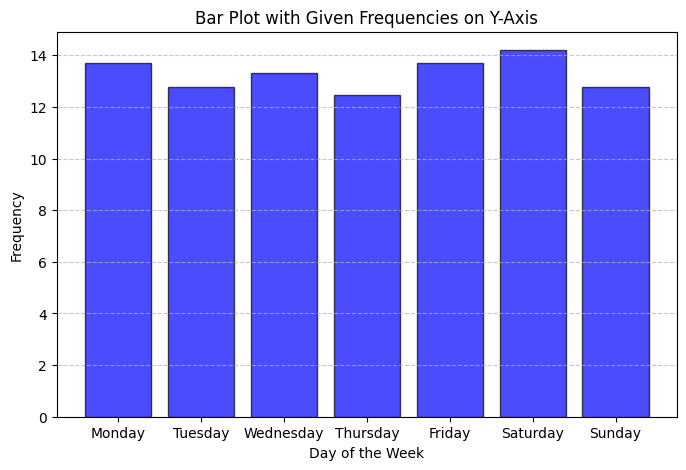

In [3]:
import matplotlib.pyplot as plt

# Given list where values represent frequencies
list1 = [13.707070707070708, 12.764705882352942, 13.326530612244898, 12.48, 
         13.699029126213592, 14.205128205128204, 12.763636363636364]

# Days of the week as x-axis labels
days = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

# Plot bar chart where list1 values are frequencies
plt.figure(figsize=(8, 5))
plt.bar(days, list1, color='blue', edgecolor='black', alpha=0.7)

# Labels and title
plt.xlabel("Day of the Week")
plt.ylabel("Frequency")
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Show the plot
plt.show()


In [8]:
import pandas as pd
file = '/Users/francescameneghello/Documents/GitHub/RIMS/BPI_Challenge_2017_W_Two_TS/results/rims/simulated_log_LSTM_BPI_Challenge_2017_W_Two_TS0.csv'
simulated_log = pd.read_csv(file)
simulated_log["time:timestamp"] = pd.to_datetime(simulated_log["time:timestamp"], utc=True)
simulated_log['caseid'] = simulated_log['caseid'].astype(str)
#simulated_log = simulated_log[(simulated_log["goal"] == "Car") & (simulated_log["type"] == "Limit raise")]

In [9]:
len(simulated_log)

9788

In [15]:
import pm4py
from log_distance_measures.config import EventLogIDs
import pandas as pd
from log_distance_measures.n_gram_distribution import n_gram_distribution_distance
from log_distance_measures.control_flow_log_distance import control_flow_log_distance
import glob

event_log_ids = EventLogIDs(  # These values are stored in DEFAULT_CSV_IDS
    case="Case ID",
    activity="Activity",
    end_time="time:timestamp",
    start_time="time:timestamp"
)

# Read and transform time attributes
original_log = pd.read_csv("/Users/francescameneghello/Downloads/BPI17_merged_log_labelled_car_limit.csv", sep=",")
original_log["time:timestamp"] = pd.to_datetime(original_log["time:timestamp"], utc=True)
original_log['Case ID'] = original_log['Case ID'].astype(str)
regular = pm4py.filter_trace_attribute_values(
    original_log,
    'label',
    ['regular'],
    case_id_key='Case ID'
)
deviant = pm4py.filter_trace_attribute_values(
    original_log,
    'label',
    ['deviant'],
    case_id_key='Case ID'
)

In [16]:
regular = set(regular['resource'].unique())
deviant = set(deviant['resource'].unique())

In [20]:
len(regular.difference(deviant))

14

In [19]:
deviant.difference(regular)

set()

In [32]:


#### metrics to consider


### control-flow with CTD, 2-gram, 3-gram


### time perspective: CTD

from log_distance_measures.circadian_workforce_distribution import circadian_workforce_distribution_distance
from log_distance_measures.config import EventLogIDs
import pandas as pd
from datetime import datetime
from log_distance_measures.control_flow_log_distance import control_flow_log_distance
from log_distance_measures.n_gram_distribution import n_gram_distribution_distance


def prefix_to_log(df, max_prefix):
    columns = ["caseid", "task", "start:timestamp", "time:timestamp", "user", "label"]
    df_new = pd.DataFrame(columns=columns)

    # Ensure columns exist
    existing_columns = df.columns.tolist()

    for index, row in df.iterrows():
        case_id = row['trace_id']
        label = row['label']

        for i in range(1, max_prefix):
            prefix_col = f'prefix_{i}'
            start_col = f'start:timestamp_{i}'
            end_col = f'time:timestamp_{i}'
            resource_col = f'org:resource_{i}'

            # Check if column exists before accessing
            if prefix_col in existing_columns and row[prefix_col] != '0':
                start = datetime.utcfromtimestamp(row[start_col])
                end = datetime.utcfromtimestamp(row[end_col])
                row_data = {
                    "caseid": case_id,
                    "task": row[prefix_col],
                    "start:timestamp": start,
                    "time:timestamp": end,
                    "user": row[resource_col],
                    "label": label
                }
                df_new = pd.concat([df_new, pd.DataFrame([row_data])], ignore_index=True)
    return df_new


# Set event log column ID mapping
simced_log = EventLogIDs(  # These values are stored in DEFAULT_CSV_IDS
    case="caseid",
    activity="task",
    end_time="time:timestamp",
    start_time="start:timestamp",
    resource = 'user'
)

labelled_log = EventLogIDs(  # These values are stored in DEFAULT_CSV_IDS
    case="Case ID",
    activity="Activity",
    end_time="time:timestamp",
    start_time="Start Timestamp",
    resource = 'resource'
)

for type_label in ['regular', 'deviant']:
    # Read and transform time attributes
    original_log = pd.read_csv("/Users/francescameneghello/Desktop/BPI17_merged_log_labelled_car_limit.csv")
    original_log[labelled_log.start_time] = pd.to_datetime(original_log[labelled_log.start_time], utc=True)
    original_log[labelled_log.end_time] = pd.to_datetime(original_log[labelled_log.end_time], utc=True)
    
    original_log = pm4py.filter_trace_attribute_values(
        original_log,
        'label',
        [type_label],
        case_id_key='Case ID'
    )
    
    method = ['SIMCED']
    metrics = ['2-Gram', '3-Gram', 'CTD']
    max_prefix = 10
    path_dict = {
        'SIMCED': ['/Users/francescameneghello/Downloads/logs_consulta_bpic17_icpm/icpm_data_gen_eval/datasets/new_logs_icpm/BPI17/BPI17_test_df_cf_simulated_aug_0.1_pref_len_20.csv', test_log]
    }

    results = {}
    for m in method:
        file = path_dict['SIMCED'][0]
        simulated_log = pd.read_csv(file)
        simulated_log = prefix_to_log(simulated_log, max_prefix)
        simulated_log[path_dict[m][1].start_time] = pd.to_datetime(simulated_log[path_dict[m][1].start_time], utc=True)
        simulated_log[path_dict[m][1].end_time] = pd.to_datetime(simulated_log[path_dict[m][1].end_time], utc=True)
        simulated_log = pm4py.filter_trace_attribute_values(
            simulated_log,
            'label',
            [type_label],
            case_id_key='caseid'
        )
        
        results[m] = {}
        for met in metrics:
            if met == 'CLFD':
                distance = control_flow_log_distance(
                    original_log, labelled_log,  # First event log and its column id mappings
                    simulated_log, path_dict[m][1]
                   )
                print(met, distance)
            elif met == '2-Gram':
                distance = n_gram_distribution_distance(
                    original_log, labelled_log,  # First event log and its column id mappings
                    simulated_log, path_dict[m][1],
                    n = 2
                )
                print(met, distance)
            elif met == '3-Gram':
                distance = n_gram_distribution_distance(
                    original_log, labelled_log,  # First event log and its column id mappings
                    simulated_log, path_dict[m][1],
                    n = 3
                )
                print(met, distance)
            else:
                distance = cycle_time_distribution_distance(
                            original_log, abelled_log,  # First event log and its column id mappings
                            simulated_log, path_dict[m][1],  # Second event log and its column id mappings
                            bin_size=pd.Timedelta(hours=1)  # Bins of 1 hour
                        )

/var/folders/w4/c4bpfq1j4l94r7q69c434q0c0000gn/T/ipykernel_65622/2990238257.py:46: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_new = pd.concat([df_new, pd.DataFrame([row_data])], ignore_index=True)


2-Gram 0.9205733858961339
3-Gram 0.9183072701165403


NameError: name 'cycle_time_distribution_distance' is not defined